<a href="https://colab.research.google.com/github/snippet-com/TopicLens-AI-News-Topic-Classifier-Using-BERT/blob/main/TopicLensAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Libraries
This cell imports the necessary Python libraries: `pandas` for data manipulation, `seaborn` for statistical data visualization, and `matplotlib.pyplot` for plotting.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Uploading Dataset
This cell uses `google.colab.files` to allow you to upload the `heart_disease_uci.csv` dataset directly into the Colab environment.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving heart_disease_uci.csv to heart_disease_uci.csv


### Loading Data and Initial Inspection
This cell reads the uploaded CSV file into a pandas DataFrame named `df`. It then performs an initial check for missing values using `df.isnull().sum()` and displays basic information about the DataFrame, including column data types and non-null counts, using `df.info()`.

In [ ]:

df= pd.read_csv("heart_disease_uci.csv")

#checking missing values
print(df.isnull().sum())

#basic info
print(df.info())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 1

### Handling Missing Values
This cell removes all rows containing any missing values (`NaN`) from the DataFrame using `df.dropna()`. After dropping the rows, it prints the sum of null values again to confirm that all missing values have been handled, and displays the updated DataFrame information with `df.info()`.

In [ ]:
df = df.dropna()
print(df.isnull().sum())
print(df.info())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        299 non-null    int64  
 1   age       299 non-null    int64  
 2   sex       299 non-null    object 
 3   dataset   299 non-null    object 
 4   cp        299 non-null    object 
 5   trestbps  299 non-null    float64
 6   chol      299 non-null    float64
 7   fbs       299 non-null    object 
 8   restecg   299 non-null    object 
 9   thalch    299 non-null    float64
 10  exang     299 non-null    object 
 11  oldpeak   299 non-null    float64
 12  slope     299 non-null    object 
 13  ca        299 non-null    float64
 14  thal      299 non-null    object 


### Data Preprocessing for Correlation Analysis
This cell prepares the data for correlation analysis. It creates a copy of the original `df`, drops irrelevant columns ('id', 'dataset'), converts the 'sex' column into a numerical format (Male=1, Female=0), and then uses one-hot encoding for other categorical columns (identified by 'object' dtype). Finally, it ensures all columns are numeric by coercing any remaining object types and drops rows with any newly introduced NaN values.

In [ ]:
import pandas as pd

# Ensure df is defined: reading the CSV and dropping NaN values
df = pd.read_csv("heart_disease_uci.csv")
df = df.dropna()

df_processed = df.copy()

# Drop irrelevant columns (e.g., 'id' and 'dataset')
df_processed = df_processed.drop(columns=['id', 'dataset'], errors='ignore')

# Convert 'sex' to numerical (Male=1, Female=0)
df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

# Identify remaining categorical columns that are 'object' type
categorical_cols = df_processed.select_dtypes(include='object').columns

# One-hot encode the remaining categorical columns
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Ensure all columns are numeric by coercing any remaining objects to numeric
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# Drop any rows with NaN values that might have been introduced during coercion
df_processed = df_processed.dropna()

### Visualizing Data Distributions with Histograms
This cell generates histograms for all numerical columns in the `df` DataFrame using `df.hist()`. The `figsize=(12,10)` argument sets the overall size of the plot, which contains multiple subplots, each showing the distribution of a single numerical feature.

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalch'}>,
        <Axes: title={'center': 'oldpeak'}>],
       [<Axes: title={'center': 'ca'}>, <Axes: title={'center': 'num'}>,
        <Axes: >]], dtype=object)

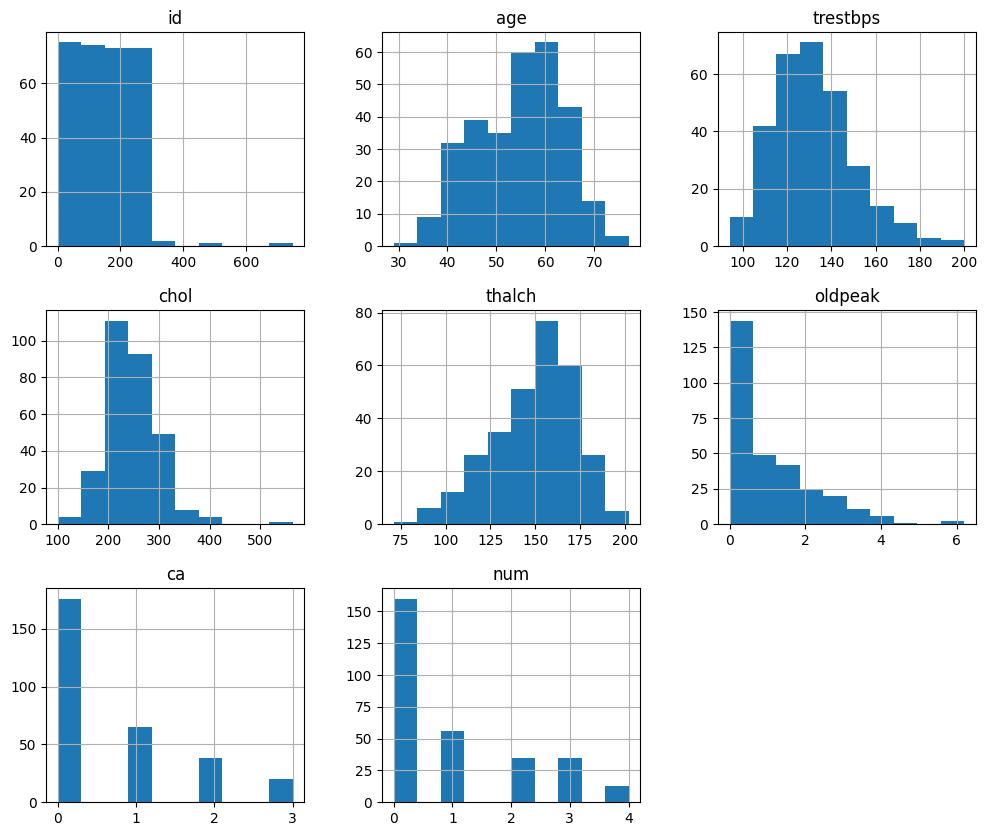

In [ ]:
df.hist(figsize=(12,10))

### Feature Correlation Heatmap
This cell generates a heatmap to visualize the correlation matrix of the preprocessed DataFrame `df_processed`. The `sns.heatmap` function is used with `annot=True` to display the correlation values, `cmap='coolwarm'` for a color-coded representation, `fmt=".2f"` to format annotations to two decimal places, and `linewidths=.5` to add lines between cells. The `plt.title` sets the plot's title, and `plt.show()` displays the heatmap.

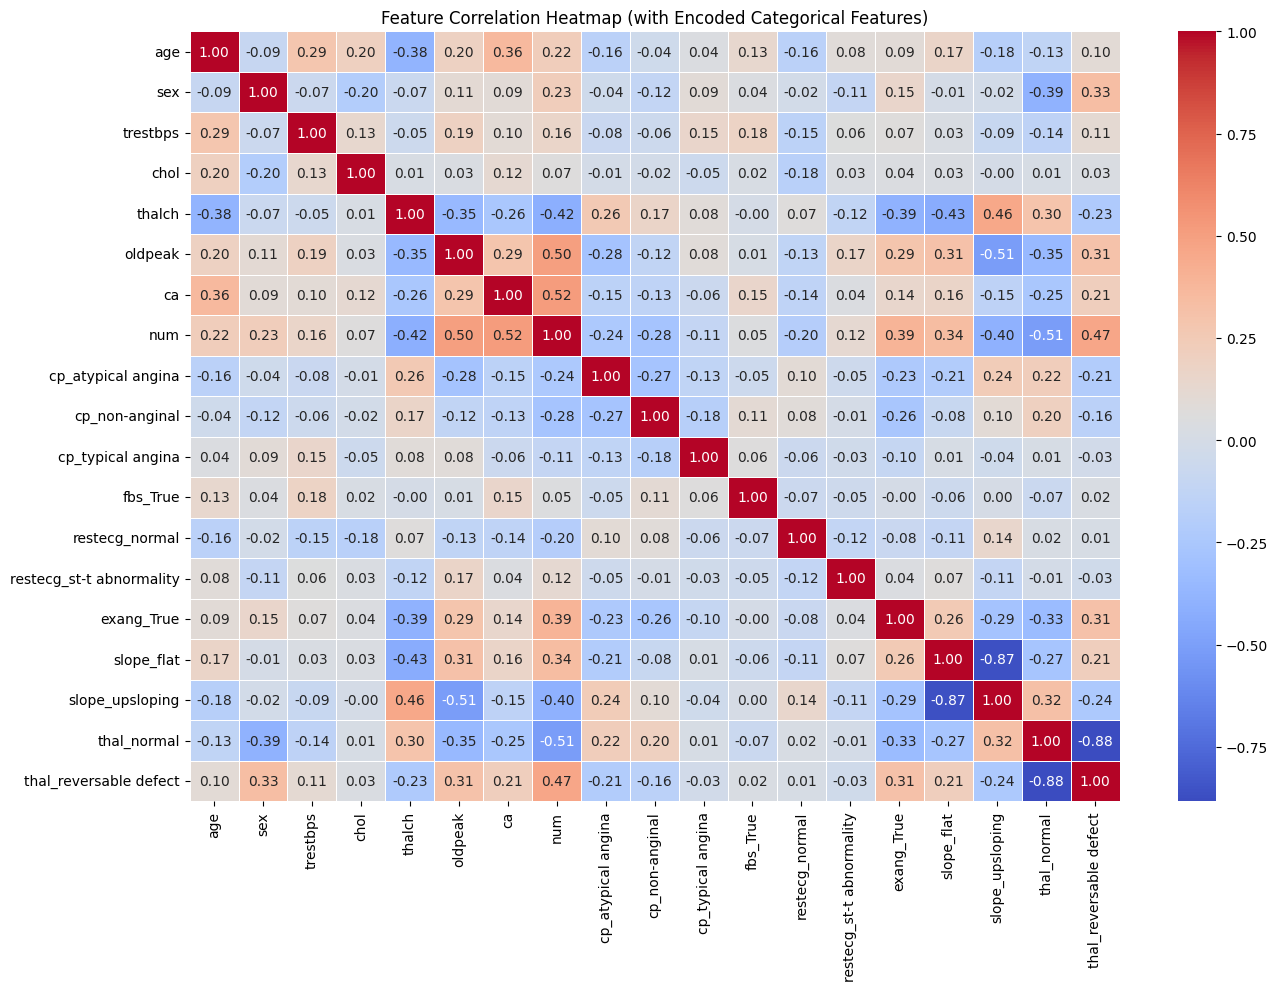

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Feature Correlation Heatmap (with Encoded Categorical Features)")
plt.show()

### Visualizing Age Distribution by Heart Disease Status
This cell generates a boxplot to visualize the distribution of 'age' across different heart disease statuses, as represented by the 'num' column. This helps in understanding if age plays a significant role in the presence of heart disease.

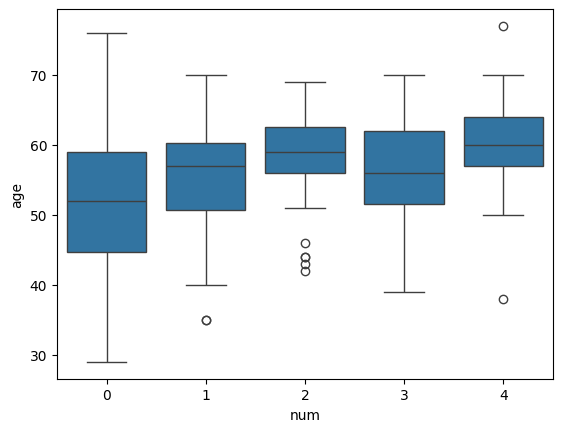

In [ ]:
sns.boxplot(x='num', y='age', data=df_processed)
plt.show()

### Exploring Categorical Feature Distributions vs. Heart Disease Status
This cell iterates through a list of categorical columns (`sex`, `cp`, `fbs`, `restecg`, `exang`) and generates a countplot for each. Each countplot shows the distribution of the categorical feature, split by the 'num' column (heart disease status). This helps in identifying how different categories within these features are associated with heart disease.

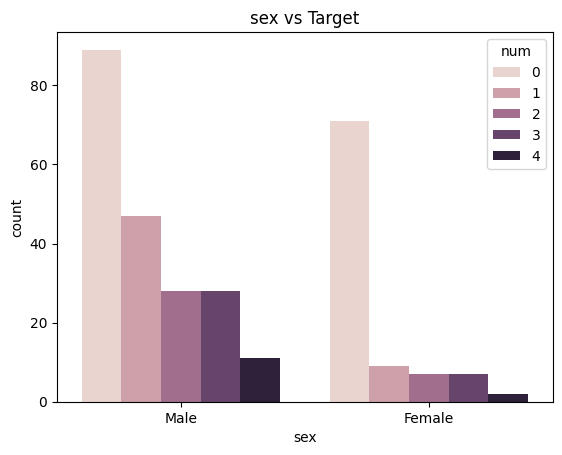

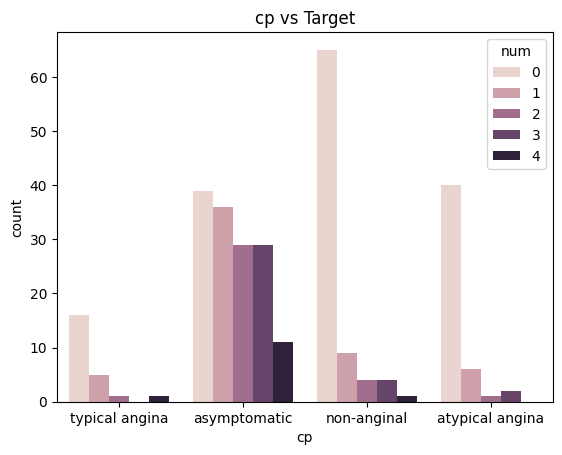

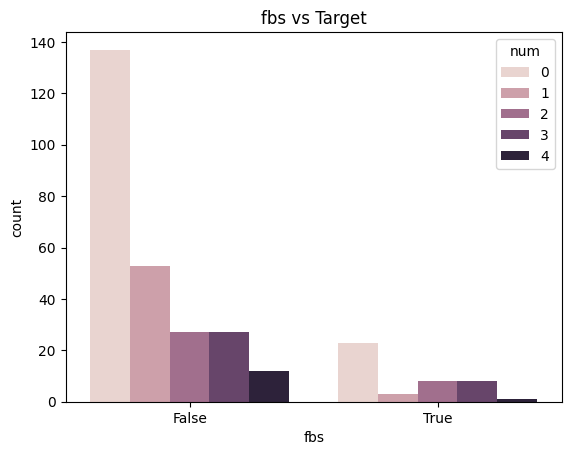

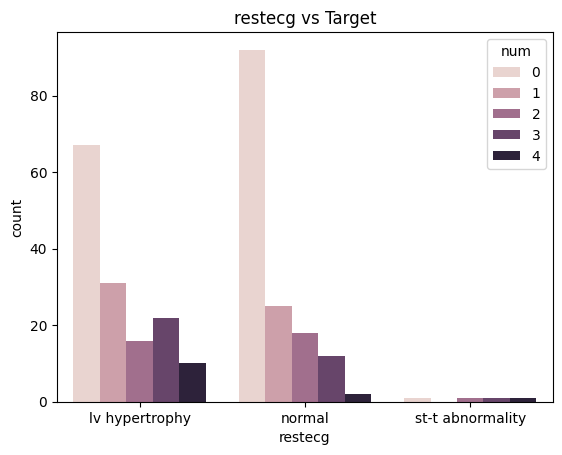

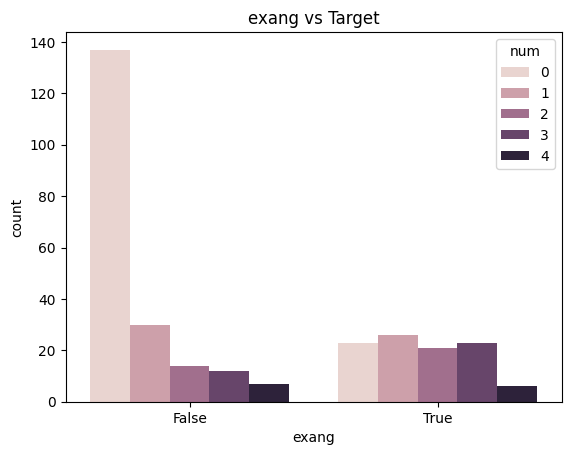

In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']

for col in categorical_cols:
    sns.countplot(x=col, hue='num', data=df)
    plt.title(f"{col} vs Target")
    plt.show()

In [ ]:
X = df_processed.drop("num", axis=1)
y = df_processed["num"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ensure X_train and X_test are derived from the correctly preprocessed X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)